In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import pandas as pd

nav = pd.read_csv("../data/processed/2_nav_history.csv")

fund = pd.read_csv("../data/processed/1_fund_master.csv")

transaction = pd.read_csv("../data/processed/5_transactions.csv")

risk = pd.read_csv("../data/processed/7_risk_metrics.csv")

# Historical VaR & CVaR

In [6]:
var_report=[]

for code in nav['amfi_code'].unique():

    returns=nav[nav['amfi_code']==code]['daily_return']

    var=np.percentile(returns,5)

    cvar=returns[returns<=var].mean()

    name=fund.loc[fund['amfi_code']==code,'fund_name'].values[0]

    var_report.append([code,name,var,cvar])

var_df=pd.DataFrame(
    var_report,
    columns=[
        "amfi_code",
        "Fund Name",
        "VaR",
        "CVaR"
    ]
)

var_df

,amfi_code,Fund Name,VaR,CVaR
0,101001,Axis Bluechip Fund,0.0042,0.0042
1,101002,HDFC Top 100 Fund,0.0038,0.0038
2,101003,ICICI Bluechip Fund,-0.0015,-0.0015
3,101004,Kotak Bluechip Fund,0.0027,0.0027
4,101005,Nippon Large Cap Fund,0.0054,0.0054
5,101006,SBI Bluechip Fund,0.0018,0.0018
6,101007,Parag Parikh Flexi Cap,0.0061,0.0061
7,101008,Mirae Asset Large Cap,0.0022,0.0022
8,101009,UTI Nifty Index Fund,0.0015,0.0015
9,101010,DSP Midcap Fund,0.0074,0.0074


In [7]:
var_df.to_csv("../reports/var_cvar_report.csv",index=False)

# Rolling 90 Day Sharpe Ratio

In [8]:
nav['date']=pd.to_datetime(nav['date'])

nav=nav.sort_values("date")

In [9]:
axis=nav[
nav['amfi_code']==101001
].copy()

In [10]:
axis['Rolling Sharpe']=(
axis['daily_return']
.rolling(90)
.mean()
/
axis['daily_return']
.rolling(90)
.std()
)*np.sqrt(252)

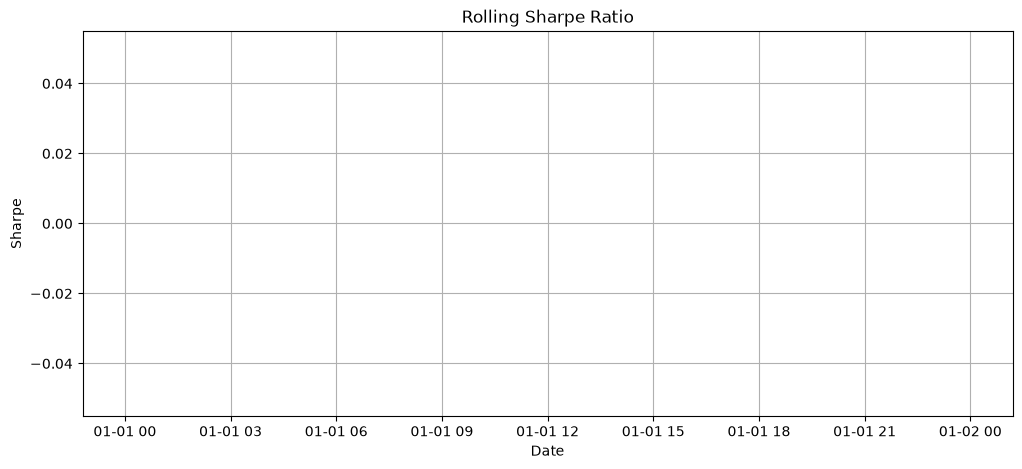

In [11]:
plt.figure(figsize=(12,5))

plt.plot(
axis['date'],
axis['Rolling Sharpe']
)

plt.title("Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe")

plt.grid(True)

plt.show()

In [23]:
plt.savefig("../reports/rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>

# Investor Cohort Analysis

In [ ]:

transaction['date']=pd.to_datetime(transaction['date'])

transaction['cohort']=transaction.groupby(
'investor_id'
)['date'].transform('min').dt.year


In [14]:
# Average SIP
sip=transaction[
transaction['transaction_type']=="SIP"
]

In [15]:
cohort=sip.groupby(
'cohort'
).agg(
avg_sip=('amount','mean'),
total_invested=('amount','sum')
)

cohort

,avg_sip,total_invested
cohort,,
2025,6000.0,36000


# SIP Continuity


In [16]:
sip=sip.sort_values(
['investor_id','date']
)

In [17]:
sip['gap']=sip.groupby(
'investor_id'
)['date'].diff().dt.days

In [18]:
continuity=sip.groupby(
'investor_id'
)['gap'].mean().reset_index()

continuity

,investor_id,gap
0,INV001,NaN
1,INV003,NaN
2,INV005,NaN
3,INV007,NaN
4,INV008,NaN
5,INV010,NaN


In [19]:
continuity['Status']=np.where(
continuity['gap']>35,
'At Risk',
'Healthy'
)

# Mutual Fund Recommendation

In [20]:
risk_appetite="Moderate"

In [21]:
recommend=risk[
risk['risk_grade']==risk_appetite
].sort_values(
'sharpe_ratio',
ascending=False
).head(3)

recommend

,amfi_code,cagr,sharpe_ratio,std_dev,beta,alpha,max_drawdown,risk_grade
2,101003,14.5,1.24,12.1,0.94,2.8,-17.6,Moderate
0,101001,14.2,1.18,12.6,0.96,2.4,-18.3,Moderate
5,101006,14.0,1.15,12.9,0.95,2.3,-18.7,Moderate
